# EduShield — Feature Engineering & Model Training

This notebook begins the machine-learning stage of the EduShield project.

## Objective

Predict whether a historical student submission is **AI-generated** using information available from multiple related datasets.

The target variable is:

`is_ai_generated`

## Feature groups

The model will combine:

- Submission behavior and writing characteristics
- Assignment design and requirements
- Student academic profile
- Course and instructor context
- Current-submission AI detector evidence from multiple tools
- Student's historical integrity/behavior context

## Leakage prevention

The following are deliberately excluded from predictors:

- `is_ai_generated` — target
- `ai_generation_source` — direct target information
- `grade` — post-submission outcome
- `feedback_score` — post-submission outcome
- case verdict/sanction fields for the current submission
- current-submission behavior events — to avoid using consequences of the submission as predictors

The final Streamlit application will use the same feature structure for a selected existing student and a newly evaluated submission.


In [1]:
# ============================================================
# IMPORTS
# ============================================================

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from xgboost import XGBClassifier

import joblib

warnings.filterwarnings("ignore")

print("EduShield feature engineering and model training started.")


EduShield feature engineering and model training started.


In [2]:
# ============================================================
# PROJECT PATHS
# ============================================================

current_path = Path.cwd()

possible_roots = [
    current_path,
    *current_path.parents
]

PROJECT_ROOT = None

for path in possible_roots:

    if (path / "data" / "processed").exists():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate EduShield/data/processed."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ML_DIR = PROJECT_ROOT / "data" / "ml"
MODEL_DIR = PROJECT_ROOT / "models"

ML_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DIR)
print("ML output:", ML_DIR)
print("Models:", MODEL_DIR)


Project root: c:\Users\adity\Documents\EduShield
Processed data: c:\Users\adity\Documents\EduShield\data\processed
ML output: c:\Users\adity\Documents\EduShield\data\ml
Models: c:\Users\adity\Documents\EduShield\models


In [3]:
# ============================================================
# LOAD PROCESSED DATA
# ============================================================

TABLE_FILES = {
    "academic_terms": "academic_terms.csv",
    "departments": "departments.csv",
    "majors": "majors.csv",
    "instructors": "instructors.csv",
    "students": "students.csv",
    "courses": "courses.csv",
    "course_offerings": "course_offerings.csv",
    "assignments": "assignments.csv",
    "submissions": "submissions.csv",
    "detector_tools": "detector_tools.csv",
    "ai_detector_results": "ai_detector_results.csv",
    "student_behavior_events": "student_behavior_events.csv",
    "integrity_cases": "integrity_cases.csv",
    "student_integrity_history": "student_integrity_history.csv"
}

data = {}

for table_name, filename in TABLE_FILES.items():

    path = PROCESSED_DIR / filename

    if not path.exists():
        raise FileNotFoundError(
            f"Processed file not found: {path}"
        )

    data[table_name] = pd.read_csv(
        path,
        low_memory=False,
        keep_default_na=False,
        na_values=[""]
    )

for table_name, df in data.items():

    print(
        f"{table_name:<32} "
        f"{len(df):>9,} rows × "
        f"{len(df.columns):>3} columns"
    )


academic_terms                           5 rows ×   6 columns
departments                             10 rows ×   3 columns
majors                                  24 rows ×   3 columns
instructors                            100 rows ×   7 columns
students                             1,500 rows ×  13 columns
courses                                 90 rows ×   8 columns
course_offerings                       261 rows ×   8 columns
assignments                            800 rows ×  20 columns
submissions                         14,983 rows ×  32 columns
detector_tools                           5 rows ×   8 columns
ai_detector_results                 74,561 rows ×  11 columns
student_behavior_events              9,984 rows ×  10 columns
integrity_cases                      1,363 rows ×  23 columns
student_integrity_history            7,500 rows ×  13 columns


## 1. Target Audit

Before building features, verify the target distribution and make sure the target exists at the submission level.


In [4]:
# ============================================================
# TARGET AUDIT
# ============================================================

submissions = data["submissions"].copy()

if "is_ai_generated" not in submissions.columns:
    raise KeyError(
        "Target column 'is_ai_generated' was not found in submissions."
    )

print("Total submissions:", len(submissions))

print("\nTarget distribution:")

target_distribution = (
    submissions["is_ai_generated"]
    .value_counts(dropna=False)
    .rename_axis("is_ai_generated")
    .reset_index(name="submission_count")
)

target_distribution["percentage"] = (
    target_distribution["submission_count"]
    / len(submissions)
    * 100
)

display(target_distribution)

if submissions["is_ai_generated"].isna().any():
    raise ValueError(
        "Target contains missing values."
    )


Total submissions: 14983

Target distribution:


,is_ai_generated,submission_count,percentage
0,False,9868,65.861309
1,True,5115,34.138691


In [5]:
# ============================================================
# NORMALIZE TARGET TYPE
# ============================================================

def normalize_bool(value):

    if isinstance(value, bool):
        return value

    text = (
        str(value)
        .strip()
        .lower()
    )

    mapping = {
        "true": True,
        "false": False,
        "yes": True,
        "no": False,
        "1": True,
        "0": False
    }

    if text not in mapping:
        raise ValueError(
            f"Unexpected boolean value: {value}"
        )

    return mapping[text]


submissions["is_ai_generated"] = (
    submissions["is_ai_generated"]
    .apply(normalize_bool)
    .astype(int)
)

print(
    submissions["is_ai_generated"]
    .value_counts()
    .sort_index()
)


is_ai_generated
0    9868
1    5115
Name: count, dtype: int64


## 2. Build Assignment + Course Context

We enrich each submission with information describing the assignment, course, offering, term, and instructor.

This makes the model aware of the academic context in which the submission occurred.


In [6]:
# ============================================================
# ASSIGNMENT + COURSE + INSTRUCTOR CONTEXT
# ============================================================

assignments = data["assignments"].copy()
course_offerings = data["course_offerings"].copy()
courses = data["courses"].copy()
instructors = data["instructors"].copy()
terms = data["academic_terms"].copy()
majors = data["majors"].copy()
departments = data["departments"].copy()
students = data["students"].copy()


# ------------------------------------------------------------
# Normalize identifiers
# ------------------------------------------------------------

id_columns_by_table = {
    "assignments": ["assignment_id", "offering_id"],
    "course_offerings": [
        "offering_id",
        "course_id",
        "term_id",
        "instructor_id"
    ],
    "courses": ["course_id", "department_id"],
    "instructors": ["instructor_id", "department_id"],
    "terms": ["term_id"],
    "majors": ["major_id", "department_id"],
    "departments": ["department_id"],
    "students": ["student_id", "major_id"]
}

for table_name, columns in id_columns_by_table.items():

    table_df = locals()[table_name]

    for column in columns:

        if column in table_df.columns:

            table_df[column] = (
                table_df[column]
                .astype("string")
                .str.strip()
                .str.upper()
            )


assignment_context = (
    assignments
    .merge(
        course_offerings,
        on="offering_id",
        how="left",
        validate="many_to_one",
        suffixes=("", "_offering")
    )
    .merge(
        courses,
        on="course_id",
        how="left",
        validate="many_to_one",
        suffixes=("", "_course")
    )
    .merge(
        instructors,
        on="instructor_id",
        how="left",
        validate="many_to_one",
        suffixes=("", "_instructor")
    )
    .merge(
        terms,
        on="term_id",
        how="left",
        validate="many_to_one",
        suffixes=("", "_term")
    )
    .merge(
        departments[
            [
                "department_id",
                "department_name"
            ]
        ],
        on="department_id",
        how="left",
        validate="many_to_one"
    )
)

print(
    "Assignment-context rows:",
    len(assignment_context)
)

display(
    assignment_context.head()
)


Assignment-context rows: 800


,assignment_id,offering_id,assignment_title,assignment_type,difficulty_level,expected_word_count,max_word_count,prompt_complexity,open_endedness,research_intensity,...,academic_rank,years_experience,teaching_load,ai_policy_adoption,term_name,academic_year,term_type,start_date,end_date,department_name
0,ASSIGN00001,OFF00255,Critical Analysis of Microeconomics II,Essay,Moderate,1204,1543,64.68,66.61,46.06,...,Professor,6.0,1,Medium,Spring 2026,2025-2026,Spring,2026-01-12,2026-05-15,Economics
1,ASSIGN00002,OFF00082,Experimental Analysis of Genetics II,Lab Report,Hard,1430,1783,61.70,49.84,52.50,...,Associate Professor,9.0,8,Medium,Fall 2025,2025-2026,Fall,2025-08-18,2025-12-19,Biology
2,ASSIGN00003,OFF00023,Research Analysis of Organizational Behavior,Research Paper,Easy,1943,2497,61.53,49.27,94.06,...,Professor,20.0,6,High,Summer 2026,2025-2026,Summer,2026-06-01,2026-07-31,Business
3,ASSIGN00004,OFF00011,Reflective Report on Modern History,Reflective Report,Moderate,1262,1488,58.88,85.38,28.44,...,Professor,1.0,3,High,Summer 2026,2025-2026,Summer,2026-06-01,2026-07-31,History
4,ASSIGN00005,OFF00097,A Comparative Study of Social Psychology II,Research Paper,Moderate,2688,3402,36.20,78.66,69.46,...,Assistant Professor,15.0,9,High,Spring 2027,2026-2027,Spring,2027-01-11,2027-05-14,Psychology


In [7]:
# ============================================================
# STUDENT PROFILE CONTEXT
# ============================================================

student_context = (
    students
    .merge(
        majors,
        on="major_id",
        how="left",
        validate="many_to_one",
        suffixes=("", "_major")
    )
    .merge(
        departments[
            [
                "department_id",
                "department_name"
            ]
        ],
        on="department_id",
        how="left",
        validate="many_to_one",
        suffixes=("", "_department")
    )
)

print(
    "Student-context rows:",
    len(student_context)
)

display(
    student_context.head()
)


Student-context rows: 1500


,student_id,first_name,last_name,gender,year_level,major_id,gpa,enrollment_date,expected_graduation_year,attendance_rate,academic_standing,scholarship_status,active_status,major_name,department_id,department_name
0,S00001,Cameron,Turner,Male,Sophomore,MAJ022,3.39,2024-10-05,2028,74.38,Good,None,Active,Business Administration,DEP10,Business
1,S00002,Jamie,Cooper,Female,Sophomore,MAJ016,2.28,2024-10-19,2028,96.29,Academic Warning,None,Active,Psychology,DEP07,Psychology
2,S00003,Casey,Parker,Male,Freshman,MAJ016,3.10,2025-10-20,2029,77.47,Good,Partial,Active,Psychology,DEP07,Psychology
3,S00004,Morgan,Reed,Male,Sophomore,MAJ019,3.14,2024-10-06,2028,93.52,Good,Partial,Active,Cultural Studies,DEP08,History
4,S00005,Parker,Mitchell,Female,Junior,MAJ007,2.72,2023-08-22,2027,81.54,Good,None,Active,Physics,DEP03,Physics


## 3. Detector Ensemble Features

Each submission may have results from multiple AI-detection tools.

Instead of keeping 75,000 detector rows separately, we create a **submission-level detector profile**.

Features include:

- One AI probability per detector
- Mean/max/min detector probability
- Detector disagreement
- Number of available detectors
- Number of detectors flagging AI
- Mean confidence
- Maximum confidence
- Detector processing success rate

Failed detector calls are not treated as evidence of human writing; they are represented as unavailable detector evidence.


In [8]:
# ============================================================
# AI DETECTOR ENSEMBLE FEATURES
# ============================================================

detector_results = data[
    "ai_detector_results"
].copy()

detector_tools = data[
    "detector_tools"
].copy()


for df, columns in [
    (
        detector_results,
        ["submission_id", "tool_id"]
    ),
    (
        detector_tools,
        ["tool_id"]
    )
]:

    for column in columns:

        df[column] = (
            df[column]
            .astype("string")
            .str.strip()
            .str.upper()
        )


detector_results = (
    detector_results
    .merge(
        detector_tools[
            [
                "tool_id",
                "tool_name"
            ]
        ],
        on="tool_id",
        how="left",
        validate="many_to_one"
    )
)


detector_results["ai_probability"] = pd.to_numeric(
    detector_results["ai_probability"],
    errors="coerce"
)

detector_results["confidence_score"] = pd.to_numeric(
    detector_results["confidence_score"],
    errors="coerce"
)


# ------------------------------------------------------------
# Normalize detector flags to numeric values
# ------------------------------------------------------------
# Explicitly convert the boolean-like detector output to
# numeric 1/0/NaN so aggregation and Parquet export remain
# Arrow-compatible.

detector_results["detected_as_ai_numeric"] = (
    detector_results["detected_as_ai"]
    .apply(
        lambda x:
            np.nan
            if pd.isna(x)
            else int(normalize_bool(x))
    )
    .astype("Float64")
)


# ------------------------------------------------------------
# Aggregate metrics
# ------------------------------------------------------------

detector_features = (
    detector_results
    .groupby("submission_id")
    .agg(
        mean_detector_ai_probability=(
            "ai_probability",
            "mean"
        ),

        max_detector_ai_probability=(
            "ai_probability",
            "max"
        ),

        min_detector_ai_probability=(
            "ai_probability",
            "min"
        ),

        std_detector_ai_probability=(
            "ai_probability",
            "std"
        ),

        mean_detector_confidence=(
            "confidence_score",
            "mean"
        ),

        max_detector_confidence=(
            "confidence_score",
            "max"
        ),

        detectors_detecting_ai=(
            "detected_as_ai_numeric",
            "sum"
        ),

        detectors_available=(
            "ai_probability",
            "count"
        ),

        detector_result_count=(
            "detector_result_id",
            "count"
        ),

        successful_detector_count=(
            "processing_status",
            lambda x:
                (x == "Success").sum()
        )
    )
    .reset_index()
)


detector_features["detector_ai_probability_range"] = (
    detector_features[
        "max_detector_ai_probability"
    ]
    -
    detector_features[
        "min_detector_ai_probability"
    ]
)

detector_features["detector_disagreement"] = (
    detector_features[
        "std_detector_ai_probability"
    ]
    .fillna(0)
)


# ------------------------------------------------------------
# Tool-specific probabilities
# ------------------------------------------------------------

tool_probability_wide = (
    detector_results
    .pivot_table(
        index="submission_id",
        columns="tool_name",
        values="ai_probability",
        aggfunc="mean"
    )
    .reset_index()
)


tool_probability_wide.columns = [
    "submission_id"
    if column == "submission_id"
    else
    (
        "detector_"
        + str(column)
        .strip()
        .lower()
        .replace(".", "")
        .replace(" ", "_")
        + "_ai_probability"
    )
    for column in tool_probability_wide.columns
]


detector_features = (
    detector_features
    .merge(
        tool_probability_wide,
        on="submission_id",
        how="left",
        validate="one_to_one"
    )
)


# ------------------------------------------------------------
# Enforce numeric detector feature dtypes
# ------------------------------------------------------------
detector_numeric_columns = [
    "mean_detector_ai_probability",
    "max_detector_ai_probability",
    "min_detector_ai_probability",
    "std_detector_ai_probability",
    "mean_detector_confidence",
    "max_detector_confidence",
    "detectors_detecting_ai",
    "detectors_available",
    "detector_result_count",
    "successful_detector_count",
    "detector_ai_probability_range",
    "detector_disagreement"
]

for column in detector_numeric_columns:
    if column in detector_features.columns:
        detector_features[column] = pd.to_numeric(
            detector_features[column],
            errors="coerce"
        )

tool_probability_columns = [
    column
    for column in detector_features.columns
    if (
        column.startswith("detector_")
        and column.endswith("_ai_probability")
    )
]

for column in tool_probability_columns:
    detector_features[column] = pd.to_numeric(
        detector_features[column],
        errors="coerce"
    )


print(
    "Detector feature columns:",
    len(detector_features.columns)
)

display(
    detector_features.head()
)


Detector feature columns: 18


,submission_id,mean_detector_ai_probability,max_detector_ai_probability,min_detector_ai_probability,std_detector_ai_probability,mean_detector_confidence,max_detector_confidence,detectors_detecting_ai,detectors_available,detector_result_count,successful_detector_count,detector_ai_probability_range,detector_disagreement,detector_copyleaks_ai_probability,detector_gptzero_ai_probability,detector_originalityai_ai_probability,detector_turnitin_ai_probability,detector_winston_ai_ai_probability
0,SUB000001,0.246452,0.59291,0.04190,0.212574,0.814926,0.97601,1.0,5,5,5,0.55101,0.212574,0.59291,0.04190,0.27913,0.12332,0.19500
1,SUB000002,0.904496,0.99000,0.78053,0.096434,0.912108,0.97065,5.0,5,5,5,0.20947,0.096434,0.98885,0.93790,0.82520,0.78053,0.99000
2,SUB000003,0.263554,0.32006,0.14264,0.074084,0.739104,0.88861,0.0,5,5,5,0.17742,0.074084,0.24577,0.14264,0.32006,0.31959,0.28971
3,SUB000004,0.208288,0.30505,0.10884,0.071905,0.796113,0.91873,0.0,5,5,5,0.19621,0.071905,0.19140,0.23989,0.30505,0.19626,0.10884
4,SUB000005,0.686520,0.91525,0.42246,0.208222,0.697876,0.87783,4.0,5,5,5,0.49279,0.208222,0.85309,0.70757,0.91525,0.42246,0.53423


## 4. Historical Student Behaviour

For each submission, we calculate only behavior events that occurred **before the submission timestamp**.

This provides historical context without allowing events generated by the current submission to leak into the target.

Examples:

- Prior AI detector flags
- Prior plagiarism flags
- Prior similarity flags
- Prior unusual collaboration
- Prior excessive copy-paste
- Prior peer reports
- Total historical integrity events
- Recent 30/90-day event counts


In [9]:
# ============================================================
# HISTORICAL STUDENT BEHAVIOR FEATURES
# ============================================================

behavior_events = data[
    "student_behavior_events"
].copy()

behavior_events["student_id"] = (
    behavior_events["student_id"]
    .astype("string")
    .str.strip()
    .str.upper()
)

behavior_events["event_date"] = pd.to_datetime(
    behavior_events["event_date"],
    errors="coerce"
)

submissions_work = submissions.copy()

submissions_work["student_id"] = (
    submissions_work["student_id"]
    .astype("string")
    .str.strip()
    .str.upper()
)

submissions_work["submitted_at"] = pd.to_datetime(
    submissions_work["submitted_at"],
    errors="coerce"
)


event_types = [
    "AI Detector Flag",
    "Similarity Flag",
    "Unusual Collaboration",
    "Rapid Submission",
    "Plagiarism Flag",
    "Excessive Copy-Paste",
    "Repeated Revision Anomaly",
    "Peer Report",
    "Unauthorized File Sharing"
]


# Create historical features submission-by-submission
historical_behavior_rows = []


for _, submission_row in submissions_work[
    [
        "submission_id",
        "student_id",
        "submitted_at"
    ]
].iterrows():

    student_id = submission_row["student_id"]
    submitted_at = submission_row["submitted_at"]

    student_events = behavior_events[
        (
            behavior_events["student_id"]
            == student_id
        )
        &
        (
            behavior_events["event_date"]
            < submitted_at
        )
    ]


    recent_30 = student_events[
        student_events["event_date"]
        >= submitted_at - pd.Timedelta(days=30)
    ]

    recent_90 = student_events[
        student_events["event_date"]
        >= submitted_at - pd.Timedelta(days=90)
    ]


    row = {
        "submission_id": submission_row[
            "submission_id"
        ],

        "prior_total_integrity_events":
            len(student_events),

        "prior_30d_integrity_events":
            len(recent_30),

        "prior_90d_integrity_events":
            len(recent_90)
    }


    for event_type in event_types:

        feature_name = (
            "prior_"
            + event_type
            .lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        row[feature_name] = int(
            (
                student_events[
                    "event_type"
                ]
                == event_type
            ).sum()
        )


    historical_behavior_rows.append(row)


historical_behavior = pd.DataFrame(
    historical_behavior_rows
)


display(
    historical_behavior.head()
)


,submission_id,prior_total_integrity_events,prior_30d_integrity_events,prior_90d_integrity_events,prior_ai_detector_flag,prior_similarity_flag,prior_unusual_collaboration,prior_rapid_submission,prior_plagiarism_flag,prior_excessive_copy_paste,prior_repeated_revision_anomaly,prior_peer_report,prior_unauthorized_file_sharing
0,SUB000001,3,1,1,2,0,0,1,0,0,0,0,0
1,SUB000002,1,0,1,0,1,0,0,0,0,0,0,0
2,SUB000003,5,0,2,3,0,0,0,1,0,0,1,0
3,SUB000004,2,0,0,1,1,0,0,0,0,0,0,0
4,SUB000005,3,1,3,1,1,0,1,0,0,0,0,0


## 5. Student Integrity History Snapshot

For each submission, attach the student's most recent integrity-history snapshot that existed before that submission.

This gives the model access to:

- Integrity score
- Trust factor
- Prior confirmed cases
- Prior dismissed cases
- Prior suspicious flags
- Prior AI flags
- Prior plagiarism flags
- Prior sanction points
- Recent integrity events
- Integrity status

The snapshot is selected strictly from the past.


In [10]:
# ============================================================
# HISTORICAL INTEGRITY SNAPSHOT
# ============================================================
#
# For each submission, attach the most recent integrity-history
# snapshot for the SAME student that occurred STRICTLY BEFORE
# the submission.
#
# We intentionally do NOT use merge_asof() here because pandas
# can be strict about sorting/grouping requirements.
#
# Instead:
#   1. Group history by student
#   2. Sort each student's snapshots chronologically
#   3. Use searchsorted() to find the latest snapshot before
#      each submission
#
# This guarantees that future integrity information cannot
# enter the feature set.
# ============================================================


# ------------------------------------------------------------
# Load source tables
# ------------------------------------------------------------

history = data[
    "student_integrity_history"
].copy()

submissions_work = data[
    "submissions"
].copy()


# ------------------------------------------------------------
# Normalize identifiers
# ------------------------------------------------------------

history["student_id"] = (
    history["student_id"]
    .astype("string")
    .str.strip()
    .str.upper()
)

submissions_work["student_id"] = (
    submissions_work["student_id"]
    .astype("string")
    .str.strip()
    .str.upper()
)


# ------------------------------------------------------------
# Normalize datetime columns
# ------------------------------------------------------------

history["snapshot_at"] = pd.to_datetime(
    history["snapshot_at"],
    errors="coerce"
)

submissions_work["submitted_at"] = pd.to_datetime(
    submissions_work["submitted_at"],
    errors="coerce"
)


# ------------------------------------------------------------
# Remove rows where the timestamp needed for the lookup
# does not exist.
# ------------------------------------------------------------

history = history[
    history["snapshot_at"].notna()
].copy()

submissions_work = submissions_work[
    submissions_work["submitted_at"].notna()
].copy()


# ------------------------------------------------------------
# Required history columns
# ------------------------------------------------------------

history_columns = [
    "student_id",
    "snapshot_at",
    "integrity_score",
    "trust_factor_score",
    "prior_confirmed_cases",
    "prior_dismissed_cases",
    "prior_suspicious_flags",
    "prior_ai_flags",
    "prior_plagiarism_flags",
    "prior_sanction_points",
    "recent_integrity_events",
    "integrity_status"
]


history_features = (
    history[
        history_columns
    ]
    .drop_duplicates(
        subset=[
            "student_id",
            "snapshot_at"
        ],
        keep="last"
    )
    .sort_values(
        [
            "student_id",
            "snapshot_at"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Build lookup dictionary
# ------------------------------------------------------------
#
# For every student we store:
#
#   snapshot timestamps
#   historical feature rows
#
# This makes the lookup simple and deterministic.
# ------------------------------------------------------------

history_lookup = {}


history_feature_columns = [
    "integrity_score",
    "trust_factor_score",
    "prior_confirmed_cases",
    "prior_dismissed_cases",
    "prior_suspicious_flags",
    "prior_ai_flags",
    "prior_plagiarism_flags",
    "prior_sanction_points",
    "recent_integrity_events",
    "integrity_status"
]


for student_id, student_history in (
    history_features
    .groupby("student_id")
):

    student_history = (
        student_history
        .sort_values("snapshot_at")
        .reset_index(drop=True)
    )

    history_lookup[
        student_id
    ] = {

        "timestamps":
            student_history[
                "snapshot_at"
            ].to_numpy(),

        "features":
            student_history[
                history_feature_columns
            ].copy()
    }


# ------------------------------------------------------------
# Prepare result containers
# ------------------------------------------------------------

result_rows = []


# ------------------------------------------------------------
# Submission-by-submission historical lookup
# ------------------------------------------------------------

for _, submission in submissions_work.iterrows():

    student_id = submission[
        "student_id"
    ]

    submitted_at = submission[
        "submitted_at"
    ]


    # Default: no prior snapshot available
    result = {

        "submission_id":
            submission["submission_id"],

        "integrity_score":
            np.nan,

        "trust_factor_score":
            np.nan,

        "prior_confirmed_cases":
            np.nan,

        "prior_dismissed_cases":
            np.nan,

        "prior_suspicious_flags":
            np.nan,

        "prior_ai_flags":
            np.nan,

        "prior_plagiarism_flags":
            np.nan,

        "prior_sanction_points":
            np.nan,

        "recent_integrity_events":
            np.nan,

        "integrity_status":
            np.nan
    }


    # --------------------------------------------------------
    # Student exists in history
    # --------------------------------------------------------

    if student_id in history_lookup:

        lookup = history_lookup[
            student_id
        ]

        timestamps = lookup[
            "timestamps"
        ]

        features = lookup[
            "features"
        ]


        # ----------------------------------------------------
        # STRICTLY BEFORE submission timestamp
        # ----------------------------------------------------
        #
        # side='left' means an exact timestamp is inserted
        # before an equal value, then subtract one.
        #
        # Therefore:
        #
        # snapshot_at < submitted_at
        #
        # is guaranteed.
        # ----------------------------------------------------

        position = np.searchsorted(
            timestamps,
            np.datetime64(
                submitted_at
            ),
            side="left"
        ) - 1


        if position >= 0:

            matched = features.iloc[
                position
            ]

            for column in history_feature_columns:

                result[column] = matched[
                    column
                ]


    result_rows.append(
        result
    )


# ------------------------------------------------------------
# Create final dataframe
# ------------------------------------------------------------

history_asof = pd.DataFrame(
    result_rows
)


# ------------------------------------------------------------
# Match datatypes
# ------------------------------------------------------------

numeric_history_columns = [
    "integrity_score",
    "trust_factor_score",
    "prior_confirmed_cases",
    "prior_dismissed_cases",
    "prior_suspicious_flags",
    "prior_ai_flags",
    "prior_plagiarism_flags",
    "prior_sanction_points",
    "recent_integrity_events"
]


for column in numeric_history_columns:

    history_asof[column] = pd.to_numeric(
        history_asof[column],
        errors="coerce"
    )


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print(
    "Historical snapshot rows:",
    len(history_asof)
)

print(
    "Submission rows used:",
    len(submissions_work)
)

print(
    "Submissions without a prior integrity snapshot:",
    history_asof[
        "integrity_score"
    ].isna().sum()
)


print(
    "\nHistory snapshot sample:"
)

display(
    history_asof.head(10)
)

Historical snapshot rows: 14983
Submission rows used: 14983
Submissions without a prior integrity snapshot: 0

History snapshot sample:


,submission_id,integrity_score,trust_factor_score,prior_confirmed_cases,prior_dismissed_cases,prior_suspicious_flags,prior_ai_flags,prior_plagiarism_flags,prior_sanction_points,recent_integrity_events,integrity_status
0,SUB000001,87.14,89.18,0,0,2,1,0,0,0,High
1,SUB000002,85.36,85.34,0,0,0,0,0,0,0,High
2,SUB000003,78.91,80.38,0,0,3,2,1,0,2,High
3,SUB000004,88.55,92.12,0,1,2,1,0,0,0,High
4,SUB000005,93.29,97.43,0,0,0,0,0,0,0,High
5,SUB000006,83.78,82.65,0,0,0,0,0,0,0,High
6,SUB000007,70.98,68.83,0,0,5,2,0,0,3,Moderate
7,SUB000008,80.25,81.33,0,0,6,2,1,0,0,High
8,SUB000009,72.98,70.80,0,1,2,2,0,0,2,Moderate
9,SUB000010,78.53,74.67,0,0,0,0,0,0,0,High


In [11]:
# ============================================================
# HISTORICAL SNAPSHOT LEAKAGE VALIDATION
# ============================================================
#
# Verify that the selected integrity snapshot is strictly
# earlier than the corresponding submission.
# ============================================================


history_check = (
    submissions_work[
        [
            "submission_id",
            "student_id",
            "submitted_at"
        ]
    ]
    .merge(
        history_features[
            [
                "student_id",
                "snapshot_at"
            ]
        ],
        on="student_id",
        how="left"
    )
)


# This is only a diagnostic check.
# A selected snapshot will be validated separately below.


# Build selected snapshot timestamp again
selected_snapshot_rows = []


for _, submission in submissions_work.iterrows():

    student_id = submission[
        "student_id"
    ]

    submitted_at = submission[
        "submitted_at"
    ]

    selected_snapshot = pd.NaT


    if student_id in history_lookup:

        timestamps = history_lookup[
            student_id
        ]["timestamps"]

        position = np.searchsorted(
            timestamps,
            np.datetime64(
                submitted_at
            ),
            side="left"
        ) - 1

        if position >= 0:

            selected_snapshot = pd.Timestamp(
                timestamps[position]
            )


    selected_snapshot_rows.append({

        "submission_id":
            submission["submission_id"],

        "student_id":
            student_id,

        "submitted_at":
            submitted_at,

        "selected_snapshot_at":
            selected_snapshot
    })


selected_snapshot_check = pd.DataFrame(
    selected_snapshot_rows
)


invalid_future_snapshots = (
    selected_snapshot_check[
        "selected_snapshot_at"
    ].notna()
    &
    (
        selected_snapshot_check[
            "selected_snapshot_at"
        ]
        >=
        selected_snapshot_check[
            "submitted_at"
        ]
    )
)


print(
    "Future snapshot violations:",
    int(
        invalid_future_snapshots.sum()
    )
)


print(
    "Exact-time snapshot violations:",
    int(
        (
            selected_snapshot_check[
                "selected_snapshot_at"
            ].notna()
            &
            (
                selected_snapshot_check[
                    "selected_snapshot_at"
                ]
                ==
                selected_snapshot_check[
                    "submitted_at"
                ]
            )
        ).sum()
    )
)

Future snapshot violations: 0
Exact-time snapshot violations: 0


## 6. Build the Master Submission-Level ML Dataset

One row will represent **one submission**.

This is the key design of EduShield's ML dataset:

`Submission → Student + Assignment + Course + Detector Ensemble + Historical Context → Target`


In [12]:
# ============================================================
# BUILD MASTER ML DATASET
# ============================================================

# Base submission table
ml_data = submissions_work.copy()


# ------------------------------------------------------------
# Student context
# ------------------------------------------------------------

student_feature_columns = [
    "student_id",
    "gender",
    "year_level",
    "major_id",
    "major_name",
    "department_name",
    "gpa",
    "attendance_rate",
    "academic_standing",
    "scholarship_status",
    "active_status"
]

student_feature_columns = [
    col
    for col in student_feature_columns
    if col in student_context.columns
]

ml_data = (
    ml_data
    .merge(
        student_context[
            student_feature_columns
        ],
        on="student_id",
        how="left",
        validate="many_to_one",
        suffixes=("", "_student")
    )
)


# ------------------------------------------------------------
# Assignment / course context
# ------------------------------------------------------------

assignment_feature_candidates = [
    "assignment_id",
    "assignment_type",
    "difficulty_level",
    "expected_word_count",
    "max_word_count",
    "prompt_complexity",
    "open_endedness",
    "research_intensity",
    "rubric_specificity",
    "requires_citations",
    "required_references",
    "research_required",
    "oral_defense_required",
    "collaboration_allowed",
    "allowed_ai_usage",
    "design_type",
    "course_id",
    "subject_area",
    "course_level",
    "credits",
    "instructor_id",
    "academic_rank",
    "years_experience",
    "teaching_load",
    "ai_policy_adoption",
    "term_id",
    "term_name",
    "academic_year",
    "delivery_mode",
    "class_size",
    "department_id",
    "department_name"
]

assignment_feature_candidates = [
    col
    for col in assignment_feature_candidates
    if col in assignment_context.columns
]


assignment_context_for_ml = (
    assignment_context[
        assignment_feature_candidates
    ]
    .drop_duplicates("assignment_id")
)


ml_data = (
    ml_data
    .merge(
        assignment_context_for_ml,
        on="assignment_id",
        how="left",
        validate="many_to_one",
        suffixes=("", "_assignment")
    )
)


# ------------------------------------------------------------
# Detector features
# ------------------------------------------------------------

ml_data = (
    ml_data
    .merge(
        detector_features,
        on="submission_id",
        how="left",
        validate="one_to_one"
    )
)


# ------------------------------------------------------------
# Historical behavior
# ------------------------------------------------------------

ml_data = (
    ml_data
    .merge(
        historical_behavior,
        on="submission_id",
        how="left",
        validate="one_to_one"
    )
)


# ------------------------------------------------------------
# Integrity history
# ------------------------------------------------------------

ml_data = (
    ml_data
    .merge(
        history_asof,
        on="submission_id",
        how="left",
        validate="one_to_one"
    )
)


print(
    "Master ML dataset shape:",
    ml_data.shape
)

display(
    ml_data.head()
)


Master ML dataset shape: (14983, 112)


,submission_id,student_id,assignment_id,submitted_at,submission_status,word_count,cited_references,similarity_score,late_submission,hours_before_deadline,...,integrity_score,trust_factor_score,prior_confirmed_cases,prior_dismissed_cases,prior_suspicious_flags,prior_ai_flags,prior_plagiarism_flags,prior_sanction_points,recent_integrity_events,integrity_status
0,SUB000001,S01424,ASSIGN00001,2026-04-11 07:54:55.549210414,Submitted,899,3.0,0.10951,False,13.08,...,87.14,89.18,0,0,2,1,0,0,0,High
1,SUB000002,S01489,ASSIGN00001,2026-04-12 19:56:11.346107781,Late,1221,4.0,0.12921,True,-22.94,...,85.36,85.34,0,0,0,0,0,0,0,High
2,SUB000003,S00046,ASSIGN00001,2026-04-11 05:46:02.388102701,Submitted,1231,5.0,0.03986,False,15.23,...,78.91,80.38,0,0,3,2,1,0,2,High
3,SUB000004,S01294,ASSIGN00001,2026-04-10 17:25:47.163574722,Submitted,1025,8.0,0.17083,False,27.57,...,88.55,92.12,0,1,2,1,0,0,0,High
4,SUB000005,S00456,ASSIGN00001,2026-04-10 21:11:57.306947502,Submitted,968,4.0,0.11451,False,23.80,...,93.29,97.43,0,0,0,0,0,0,0,High


## 7. Feature Engineering

We now derive features that describe how the submission compares with its academic context.


In [13]:
# ============================================================
# SUBMISSION-LEVEL DERIVED FEATURES
# ============================================================

# ------------------------------------------------------------
# Word-count ratios
# ------------------------------------------------------------

ml_data["word_count_vs_expected"] = (
    ml_data["word_count"]
    /
    ml_data["expected_word_count"]
)

ml_data["word_count_vs_max"] = (
    ml_data["word_count"]
    /
    ml_data["max_word_count"]
)

ml_data["word_count_deviation"] = (
    ml_data["word_count"]
    -
    ml_data["expected_word_count"]
)


# ------------------------------------------------------------
# Citation behaviour
# ------------------------------------------------------------

ml_data["citation_gap"] = (
    ml_data["cited_references"]
    -
    ml_data["required_references"]
)

ml_data["references_per_1000_words"] = (
    ml_data["cited_references"]
    /
    ml_data["word_count"].clip(lower=1)
    * 1000
)


# ------------------------------------------------------------
# Editing / effort behaviour
# ------------------------------------------------------------

ml_data["edits_per_100_words"] = (
    ml_data["editing_sessions"]
    /
    ml_data["word_count"].clip(lower=1)
    * 100
)

ml_data["revisions_per_100_words"] = (
    ml_data["revision_count"]
    /
    ml_data["word_count"].clip(lower=1)
    * 100
)

ml_data["drafts_per_100_words"] = (
    ml_data["draft_count"]
    /
    ml_data["word_count"].clip(lower=1)
    * 100
)

ml_data["words_per_minute"] = (
    ml_data["word_count"]
    /
    ml_data["time_spent_minutes"].clip(lower=1)
)


# ------------------------------------------------------------
# Content profile
# ------------------------------------------------------------

ml_data["linguistic_complexity"] = (
    (
        ml_data["vocabulary_richness"]
        +
        ml_data["lexical_diversity"]
        +
        ml_data["semantic_coherence"]
    )
    / 3
)


ml_data["ai_style_signal"] = (
    (
        ml_data["perplexity_score"]
        +
        ml_data["burstiness_score"]
        +
        ml_data["typing_consistency"]
    )
    / 3
)


# ------------------------------------------------------------
# Submission timing
# ------------------------------------------------------------

ml_data["submission_hour"] = (
    pd.to_datetime(
        ml_data["submitted_at"],
        errors="coerce"
    )
    .dt.hour
)

ml_data["submission_day_of_week"] = (
    pd.to_datetime(
        ml_data["submitted_at"],
        errors="coerce"
    )
    .dt.dayofweek
)


# ------------------------------------------------------------
# Detector ensemble
# ------------------------------------------------------------

ml_data["detector_coverage"] = (
    ml_data["detectors_available"]
    /
    ml_data["detector_result_count"]
    .replace(0, np.nan)
)

ml_data["detector_ai_flag_rate"] = (
    ml_data["detectors_detecting_ai"]
    /
    ml_data["detectors_available"]
    .replace(0, np.nan)
)


# ------------------------------------------------------------
# Student historical risk/context
# ------------------------------------------------------------

ml_data["prior_case_count"] = (
    ml_data["prior_confirmed_cases"]
    +
    ml_data["prior_dismissed_cases"]
)

ml_data["prior_integrity_event_density"] = (
    ml_data["prior_90d_integrity_events"]
    /
    ml_data["prior_total_integrity_events"]
    .replace(0, np.nan)
)


print(
    "Feature engineering completed."
)

print(
    "Current dataset shape:",
    ml_data.shape
)


Feature engineering completed.
Current dataset shape: (14983, 129)


## 8. Leakage Audit

Before modeling, explicitly remove fields that could leak the target or information that would only become known after the prediction point.


In [14]:
# ============================================================
# LEAKAGE AUDIT
# ============================================================

LEAKAGE_COLUMNS = [
    # Direct target
    "is_ai_generated",

    # Direct target-related source
    "ai_generation_source",

    # Post-submission outcomes
    "grade",
    "feedback_score"
]


# Current-submission events are excluded from the feature set.
# Historical event counts remain because they only use dates
# before submitted_at.


# Remove IDs and raw timestamp fields from model predictors
ID_COLUMNS = [
    "submission_id",
    "student_id",
    "assignment_id",
    "course_id",
    "offering_id",
    "term_id",
    "instructor_id",
    "major_id",
    "department_id"
]

TIMESTAMP_COLUMNS = [
    "submitted_at",
    "assignment_open_at",
    "submission_deadline",
    "submission_date"
]


EXCLUDE_FROM_MODEL = (
    LEAKAGE_COLUMNS
    + ID_COLUMNS
    + TIMESTAMP_COLUMNS
)


available_exclusions = [
    col
    for col in EXCLUDE_FROM_MODEL
    if col in ml_data.columns
]


print(
    "Excluded from modeling:"
)

for column in available_exclusions:
    print(" -", column)


Excluded from modeling:
 - is_ai_generated
 - ai_generation_source
 - grade
 - feedback_score
 - submission_id
 - student_id
 - assignment_id
 - course_id
 - term_id
 - instructor_id
 - major_id
 - department_id
 - submitted_at


In [15]:
# ============================================================
# CHECK FOR TARGET-LIKE COLUMNS
# ============================================================

target_like_columns = [
    col
    for col in ml_data.columns
    if (
        "ai_generated" in col.lower()
        or
        "generation_source" in col.lower()
    )
]


print(
    "Potential target-related columns:"
)

for column in target_like_columns:
    print(
        " -",
        column
    )


Potential target-related columns:
 - is_ai_generated
 - ai_generation_source


## 9. Feature Matrix

We now build the model-ready feature matrix.

Categorical variables will use one-hot encoding.

Numeric variables will use median imputation.

The model pipeline will contain preprocessing + estimator together so the exact same transformations can later be reused by Streamlit.


In [16]:
# ============================================================
# MODEL FEATURE MATRIX
# ============================================================

target_column = "is_ai_generated"

X = ml_data.drop(
    columns=[
        col
        for col in EXCLUDE_FROM_MODEL
        if col in ml_data.columns
    ],
    errors="ignore"
)

y = ml_data[
    target_column
].astype(int)


# Remove helper columns that contain no useful variation
constant_columns = [
    col
    for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

if constant_columns:

    print(
        "Removing constant columns:",
        constant_columns
    )

    X = X.drop(
        columns=constant_columns
    )


categorical_features = (
    X.select_dtypes(
        include=[
            "object",
            "string",
            "category",
            "bool"
        ]
    )
    .columns
    .tolist()
)


numeric_features = [
    col
    for col in X.columns
    if col not in categorical_features
]


print(
    "Total model features:",
    X.shape[1]
)

print(
    "Numeric features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)


Total model features: 116
Numeric features: 90
Categorical features: 26


## 10. Train/Test Split

A stratified split keeps the AI-generated/human class proportions approximately consistent in both sets.


In [17]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


print(
    "Training rows:",
    len(X_train)
)

print(
    "Testing rows:",
    len(X_test)
)

print(
    "\nTraining target distribution:"
)

print(
    y_train.value_counts(
        normalize=True
    ).sort_index()
)

print(
    "\nTesting target distribution:"
)

print(
    y_test.value_counts(
        normalize=True
    ).sort_index()
)


Training rows: 11986
Testing rows: 2997

Training target distribution:
is_ai_generated
0    0.658602
1    0.341398
Name: proportion, dtype: float64

Testing target distribution:
is_ai_generated
0    0.658659
1    0.341341
Name: proportion, dtype: float64


In [18]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


print("Preprocessing pipeline ready.")


Preprocessing pipeline ready.


## 11. Model Training

We will train three different estimators:

- Logistic Regression — interpretable baseline
- Random Forest — nonlinear interactions
- XGBoost — gradient-boosted nonlinear model

The same preprocessing is wrapped into each pipeline.


In [19]:
# ============================================================
# DEFINE MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
}


pipelines = {}

for model_name, estimator in models.items():

    pipelines[model_name] = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                estimator
            )
        ]
    )


print(
    "Models prepared:",
    list(pipelines.keys())
)


Models prepared: ['Logistic Regression', 'Random Forest', 'XGBoost']


In [20]:
# ============================================================
# TRAIN AND EVALUATE MODELS
# ============================================================

results = []
fitted_models = {}


for model_name, pipeline in pipelines.items():

    print(
        f"Training {model_name}..."
    )

    pipeline.fit(
        X_train,
        y_train
    )

    fitted_models[
        model_name
    ] = pipeline


    predictions = pipeline.predict(
        X_test
    )

    probabilities = pipeline.predict_proba(
        X_test
    )[:, 1]


    results.append({

        "model":
            model_name,

        "accuracy":
            accuracy_score(
                y_test,
                predictions
            ),

        "precision":
            precision_score(
                y_test,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_test,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_test,
                predictions,
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                y_test,
                probabilities
            )
    })


model_results = (
    pd.DataFrame(results)
    .sort_values(
        "roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    model_results.style.format(
        {
            "accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}",
            "roc_auc": "{:.4f}"
        }
    )
)


Training Logistic Regression...
Training Random Forest...
Training XGBoost...


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.9997,0.9990,1.0000,0.9995,1.0000
1,XGBoost,0.9990,0.9990,0.9980,0.9985,1.0000
2,Random Forest,0.9997,1.0000,0.9990,0.9995,1.0000


In [21]:
# ============================================================
# DETAILED CLASSIFICATION REPORTS
# ============================================================

for model_name, pipeline in fitted_models.items():

    predictions = pipeline.predict(
        X_test
    )

    print(
        "\n" + "=" * 70
    )

    print(
        model_name
    )

    print(
        "=" * 70
    )

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "Human Written",
                "AI Generated"
            ],
            zero_division=0
        )
    )



Logistic Regression
               precision    recall  f1-score   support

Human Written       1.00      1.00      1.00      1974
 AI Generated       1.00      1.00      1.00      1023

     accuracy                           1.00      2997
    macro avg       1.00      1.00      1.00      2997
 weighted avg       1.00      1.00      1.00      2997


Random Forest
               precision    recall  f1-score   support

Human Written       1.00      1.00      1.00      1974
 AI Generated       1.00      1.00      1.00      1023

     accuracy                           1.00      2997
    macro avg       1.00      1.00      1.00      2997
 weighted avg       1.00      1.00      1.00      2997


XGBoost
               precision    recall  f1-score   support

Human Written       1.00      1.00      1.00      1974
 AI Generated       1.00      1.00      1.00      1023

     accuracy                           1.00      2997
    macro avg       1.00      1.00      1.00      2997
 weighted av

## 12. Confusion Matrix for the Selected Final Model

The final model will be selected based on the validation results rather than hard-coding a choice before seeing the metrics.


In [22]:
# ============================================================
# SELECT FINAL MODEL
# ============================================================

# For this project we prioritize a balance of:
# ROC-AUC, F1, precision and recall.
#
# The selection is made programmatically using a composite
# validation criterion rather than choosing a model in advance.

selection_scores = (
    model_results[
        [
            "model",
            "f1",
            "roc_auc",
            "precision",
            "recall"
        ]
    ]
    .copy()
)

selection_scores["selection_score"] = (
    0.30 * selection_scores["f1"]
    +
    0.30 * selection_scores["roc_auc"]
    +
    0.20 * selection_scores["precision"]
    +
    0.20 * selection_scores["recall"]
)

selection_scores = (
    selection_scores
    .sort_values(
        "selection_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    selection_scores.style.format(
        {
            "f1": "{:.4f}",
            "roc_auc": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "selection_score": "{:.4f}"
        }
    )
)


FINAL_MODEL_NAME = selection_scores.loc[
    0,
    "model"
]

final_pipeline = fitted_models[
    FINAL_MODEL_NAME
]


print(
    "Final model selected:",
    FINAL_MODEL_NAME
)


,model,f1,roc_auc,precision,recall,selection_score
0,Logistic Regression,0.9995,1.0000,0.9990,1.0000,0.9997
1,Random Forest,0.9995,1.0000,1.0000,0.9990,0.9997
2,XGBoost,0.9985,1.0000,0.9990,0.9980,0.9990


Final model selected: Logistic Regression


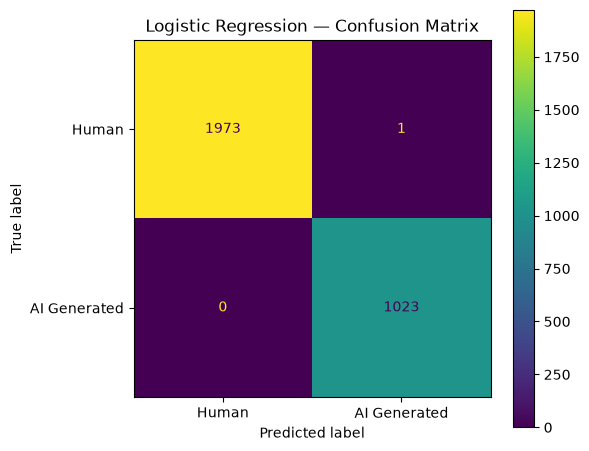

In [23]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

final_predictions = final_pipeline.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    final_predictions
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Human",
        "AI Generated"
    ]
).plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    f"{FINAL_MODEL_NAME} — Confusion Matrix"
)

plt.tight_layout()
plt.show()


## 13. Baseline vs Expanded Feature Set

To demonstrate the value of the relational design, we also create a baseline feature set using primarily the submission + assignment information.

Then we compare it with the expanded model containing student, course, instructor, detector, behavior-history and integrity-history features.


In [24]:
# ============================================================
# BASELINE FEATURE SET
# ============================================================

baseline_exclusions = [
    col
    for col in ml_data.columns
    if (
        col.startswith("detector_")
        or col.startswith("mean_detector")
        or col.startswith("max_detector")
        or col.startswith("min_detector")
        or col.startswith("std_detector")
        or col.startswith("detectors_")
        or col.startswith("prior_")
        or col.startswith("recent_")
        or col in [
            "integrity_score",
            "trust_factor_score",
            "prior_case_count",
            "prior_integrity_event_density"
        ]
    )
]


baseline_exclusions += [
    col
    for col in [
        "is_ai_generated",
        "ai_generation_source",
        "grade",
        "feedback_score",
        "submission_id",
        "student_id",
        "assignment_id",
        "course_id",
        "offering_id",
        "term_id",
        "instructor_id",
        "major_id",
        "department_id",
        "submitted_at",
        "assignment_open_at",
        "submission_deadline"
    ]
    if col in ml_data.columns
]


X_baseline = ml_data.drop(
    columns=list(set(baseline_exclusions)),
    errors="ignore"
)

y_baseline = ml_data[
    "is_ai_generated"
]


baseline_categorical = (
    X_baseline
    .select_dtypes(
        include=[
            "object",
            "string",
            "category",
            "bool"
        ]
    )
    .columns
    .tolist()
)

baseline_numeric = [
    col
    for col in X_baseline.columns
    if col not in baseline_categorical
]


baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median",
                            add_indicator=True
                        )
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    )
                ]
            ),
            baseline_numeric
        ),

        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        )
                    )
                ]
            ),
            baseline_categorical
        )
    ]
)


Xb_train, Xb_test, yb_train, yb_test = (
    train_test_split(
        X_baseline,
        y_baseline,
        test_size=0.20,
        stratify=y_baseline,
        random_state=42
    )
)


baseline_model = Pipeline(
    steps=[
        (
            "preprocessor",
            baseline_preprocessor
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=400,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.85,
                colsample_bytree=0.85,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


baseline_model.fit(
    Xb_train,
    yb_train
)


baseline_pred = baseline_model.predict(
    Xb_test
)

baseline_prob = baseline_model.predict_proba(
    Xb_test
)[:, 1]


baseline_metrics = {

    "accuracy":
        accuracy_score(
            yb_test,
            baseline_pred
        ),

    "precision":
        precision_score(
            yb_test,
            baseline_pred,
            zero_division=0
        ),

    "recall":
        recall_score(
            yb_test,
            baseline_pred,
            zero_division=0
        ),

    "f1":
        f1_score(
            yb_test,
            baseline_pred,
            zero_division=0
        ),

    "roc_auc":
        roc_auc_score(
            yb_test,
            baseline_prob
        )
}


print(
    "Baseline feature count:",
    X_baseline.shape[1]
)

display(
    pd.DataFrame(
        [baseline_metrics],
        index=["Baseline XGBoost"]
    )
)


Baseline feature count: 75


,accuracy,precision,recall,f1,roc_auc
Baseline XGBoost,0.958959,0.948207,0.930596,0.939319,0.992762


In [25]:
# ============================================================
# BASELINE VS EXPANDED MODEL
# ============================================================

expanded_metrics = (
    model_results[
        model_results["model"] == "XGBoost"
    ][
        [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ]
    ]
    .copy()
)

expanded_metrics.index = [
    "Expanded XGBoost"
]

baseline_metrics_df = pd.DataFrame(
    [baseline_metrics],
    index=["Baseline XGBoost"]
)


baseline_vs_expanded = pd.concat(
    [
        baseline_metrics_df,
        expanded_metrics
    ]
)

display(
    baseline_vs_expanded.style.format(
        "{:.4f}"
    )
)


,accuracy,precision,recall,f1,roc_auc
Baseline XGBoost,0.9590,0.9482,0.9306,0.9393,0.9928
Expanded XGBoost,0.9990,0.9990,0.9980,0.9985,1.0000


## 14. Feature Importance

For the final tree-based model, inspect which engineered features contribute most strongly.

This is useful for the Streamlit app because the app can later show the most relevant factors behind a prediction.


In [26]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

if FINAL_MODEL_NAME in [
    "Random Forest",
    "XGBoost"
]:

    fitted_preprocessor = (
        final_pipeline
        .named_steps["preprocessor"]
    )

    fitted_model = (
        final_pipeline
        .named_steps["model"]
    )


    feature_names = (
        fitted_preprocessor
        .get_feature_names_out()
    )


    importances = (
        fitted_model
        .feature_importances_
    )


    feature_importance = (
        pd.DataFrame({

            "feature":
                feature_names,

            "importance":
                importances

        })
        .sort_values(
            "importance",
            ascending=False
        )
        .reset_index(drop=True)
    )


    display(
        feature_importance.head(30)
    )

else:

    print(
        "Feature-importance extraction is handled "
        "differently for the selected linear model."
    )


Feature-importance extraction is handled differently for the selected linear model.


## 15. Export the Model Dataset and Model Artifacts

Before exporting the submission-level ML dataset, the notebook performs a final dtype audit to catch mixed Python types that can cause PyArrow/Parquet failures.

The ML dataset is then exported with Arrow-safe numeric/string coercion, followed by a Parquet round-trip test to confirm that the saved file can be read back successfully with the expected shape and target column.


In [27]:
# ============================================================
# PARQUET / ARROW DTYPE AUDIT
# ============================================================

dtype_audit = []

for column in ml_data.columns:

    python_types = sorted(
        ml_data[column]
        .dropna()
        .map(lambda x: type(x).__name__)
        .unique()
        .tolist()
    )

    dtype_audit.append({
        "column": column,
        "dtype": str(
            ml_data[column].dtype
        ),
        "python_types": ", ".join(python_types)
    })


dtype_audit = pd.DataFrame(
    dtype_audit
)


print(
    "Columns with object dtype:"
)

display(
    dtype_audit[
        dtype_audit["dtype"] == "object"
    ]
)


print(
    "\nMixed Python types:"
)

display(
    dtype_audit[
        dtype_audit["python_types"].str.contains(
            ",",
            na=False
        )
    ]
)


Columns with object dtype:


,column,dtype,python_types
0,submission_id,object,str
2,assignment_id,object,str



Mixed Python types:


,column,dtype,python_types


In [28]:
# ============================================================
# EXPORT ML DATASET
# ============================================================

ml_data_export = ml_data.copy()


# ------------------------------------------------------------
# Force known numeric fields to numeric dtype
# ------------------------------------------------------------
numeric_columns = [
    column
    for column in ml_data_export.columns
    if pd.api.types.is_numeric_dtype(
        ml_data_export[column]
    )
    or column in [
        "detectors_detecting_ai",
        "detectors_available",
        "detector_result_count",
        "successful_detector_count"
    ]
]


for column in numeric_columns:

    ml_data_export[column] = pd.to_numeric(
        ml_data_export[column],
        errors="coerce"
    )


# ------------------------------------------------------------
# Preserve target as nullable integer
# ------------------------------------------------------------
if "is_ai_generated" in ml_data_export.columns:

    ml_data_export["is_ai_generated"] = (
        pd.to_numeric(
            ml_data_export["is_ai_generated"],
            errors="coerce"
        )
        .astype("Int64")
    )


# ------------------------------------------------------------
# Convert remaining Python-object columns to strings
# ------------------------------------------------------------
# This prevents PyArrow from encountering mixed object values
# such as bool + int in the same column.

for column in ml_data_export.columns:

    if ml_data_export[column].dtype == "object":

        ml_data_export[column] = (
            ml_data_export[column]
            .astype("string")
        )


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

ml_output_path = (
    ML_DIR
    / "edushield_submission_ml_data.parquet"
)


ml_data_export.to_parquet(
    ml_output_path,
    index=False,
    engine="pyarrow"
)


print(
    "ML dataset saved:",
    ml_output_path
)

print(
    "Shape:",
    ml_data_export.shape
)


ML dataset saved: c:\Users\adity\Documents\EduShield\data\ml\edushield_submission_ml_data.parquet
Shape: (14983, 129)


In [29]:
# ============================================================
# PARQUET ROUND-TRIP VALIDATION
# ============================================================

test_read = pd.read_parquet(
    ml_output_path,
    engine="pyarrow"
)


print(
    "Parquet round-trip successful."
)

print(
    "Rows:",
    len(test_read)
)

print(
    "Columns:",
    len(test_read.columns)
)

print(
    "Shape:",
    test_read.shape
)

print(
    "\nTarget distribution:"
)

print(
    test_read[
        "is_ai_generated"
    ].value_counts(
        dropna=False
    )
)


# Final check: exported schema should match source schema
schema_match = (
    list(test_read.columns)
    == list(ml_data_export.columns)
)

print(
    "\nColumn order/schema match:",
    schema_match
)


Parquet round-trip successful.
Rows: 14983
Columns: 129
Shape: (14983, 129)

Target distribution:
is_ai_generated
0    9868
1    5115
Name: count, dtype: Int64

Column order/schema match: True


In [30]:
# ============================================================
# EXPORT MODEL + FEATURE METADATA
# ============================================================

model_path = MODEL_DIR / "edushield_ai_prediction_pipeline.joblib"

joblib.dump(
    final_pipeline,
    model_path
)


feature_manifest = pd.DataFrame({

    "feature_name":
        X.columns,

    "data_type":
        [
            str(X[col].dtype)
            for col in X.columns
        ],

    "feature_group":
        [
            (
                "categorical"
                if col in categorical_features
                else "numeric"
            )
            for col in X.columns
        ]
})


feature_manifest.to_csv(
    MODEL_DIR / "feature_manifest.csv",
    index=False
)


model_results.to_csv(
    MODEL_DIR / "model_comparison.csv",
    index=False
)


selection_scores.to_csv(
    MODEL_DIR / "model_selection_scores.csv",
    index=False
)


print(
    "Model saved:",
    model_path
)

print(
    "Feature manifest saved."
)

print(
    "Model comparison saved."
)


Model saved: c:\Users\adity\Documents\EduShield\models\edushield_ai_prediction_pipeline.joblib
Feature manifest saved.
Model comparison saved.


## 16. Save Test Predictions

These predictions will be useful later for evaluation visualizations and for building the presentation.


In [31]:
# ============================================================
# SAVE TEST PREDICTIONS
# ============================================================

test_prediction_output = ml_data.loc[
    X_test.index,
    [
        "submission_id",
        "student_id",
        "assignment_id",
        "is_ai_generated"
    ]
].copy()


test_prediction_output[
    "predicted_is_ai_generated"
] = final_predictions


test_prediction_output[
    "prediction_probability"
] = final_pipeline.predict_proba(
    X_test
)[:, 1]


test_prediction_output.to_csv(
    MODEL_DIR / "test_predictions.csv",
    index=False
)


print(
    "Test predictions saved."
)

display(
    test_prediction_output.head(20)
)


Test predictions saved.


,submission_id,student_id,assignment_id,is_ai_generated,predicted_is_ai_generated,prediction_probability
12955,SUB012971,S01341,ASSIGN00691,True,1,9.999998e-01
6291,SUB006300,S00063,ASSIGN00338,True,1,1.000000e+00
8711,SUB008722,S00604,ASSIGN00464,False,0,2.655887e-09
7559,SUB007569,S00463,ASSIGN00402,True,1,1.000000e+00
5126,SUB005134,S00565,ASSIGN00273,False,0,2.842570e-07
7764,SUB007774,S01176,ASSIGN00413,False,0,7.249685e-06
2967,SUB002972,S01498,ASSIGN00159,False,0,1.775159e-07
1283,SUB001284,S00783,ASSIGN00070,True,1,9.999388e-01
11899,SUB011914,S00427,ASSIGN00635,True,1,9.999597e-01
4047,SUB004053,S00652,ASSIGN00216,True,1,1.000000e+00


## End of initial ML stage

The notebook now produces:

- Submission-level ML dataset
- Expanded relational feature set
- Detector ensemble features
- Historical student behavior features
- Integrity-history features
- Baseline vs expanded model comparison
- Trained preprocessing + model pipeline
- Feature manifest
- Test predictions
- Parquet / Arrow dtype audit
- Verified Parquet round-trip

The Streamlit application should load the saved pipeline and recreate the same feature structure for an existing student plus a new submission evaluation.
